# Классификация текстов с применением RNN


**Table of contents**<a id='toc0_'></a>    
- 1. [Раздел 1. Загрузка данных](#toc1_)    
  - 1.1. [Research](#toc1_1_)    
    - 1.1.1. [Балансировка классов](#toc1_1_1_)    
    - 1.1.2. [Удаление нерелевантного признака](#toc1_1_2_)    
- 2. [Раздел 2. Предварительная обработка](#toc2_)    
  - 2.1. [Research](#toc2_1_)    
    - 2.1.1. [Очистка сырого текста](#toc2_1_1_)    
    - 2.1.2. [Токенизация](#toc2_1_2_)    
      - 2.1.2.1. [Токенизатор nltk - ToktokTokenizer](#toc2_1_2_1_)    
      - 2.1.2.2. [Razdel](#toc2_1_2_2_)    
    - 2.1.3. [Лемматизация](#toc2_1_3_)    
    - 2.1.4. [Разделение на train/val/test](#toc2_1_4_)    
    - 2.1.5. [Кодирование целевой переменной](#toc2_1_5_)    
- 3. [Раздел 3. Векторизация](#toc3_)    
  - 3.1. [Research](#toc3_1_)    
    - 3.1.1. [Navec](#toc3_1_1_)    
    - 3.1.2. [FastText - обучаем с нуля](#toc3_1_2_)    
    - 3.1.3. [Обучаемые NN-эмбеддинги](#toc3_1_3_)    
- 4. [Раздел 4. Обучение нейронных сетей](#toc4_)    
  - 4.1. [Research](#toc4_1_)    
    - 4.1.1. [Подготовка эмбеддингов](#toc4_1_1_)    
      - 4.1.1.1. [Navec Embeddings](#toc4_1_1_1_)    
      - 4.1.1.2. [FastText Embeddings](#toc4_1_1_2_)    
      - 4.1.1.3. [Обучаемые NN-эмбеддинги](#toc4_1_1_3_)    
    - 4.1.2. [Сеть на базе блока RNN (biRNN)](#toc4_1_2_)    
      - 4.1.2.1. [Реализация нейронной сети](#toc4_1_2_1_)    
      - 4.1.2.2. [Реализация нейронной сети (Navec)](#toc4_1_2_2_)    
      - 4.1.2.3. [Реализация нейронной сети (FastText)](#toc4_1_2_3_)    
      - 4.1.2.4. [Реализация нейронной сети (NN-эмбеддинги)](#toc4_1_2_4_)    
    - 4.1.3. [Сеть на базе блока LSTM (biLSTM)](#toc4_1_3_)    
      - 4.1.3.1. [Реализация нейронной сети](#toc4_1_3_1_)    
      - 4.1.3.2. [Реализация нейронной сети (Navec)](#toc4_1_3_2_)    
      - 4.1.3.3. [Реализация нейронной сети (FastText)](#toc4_1_3_3_)    
      - 4.1.3.4. [Реализация нейронной сети (NN-эмбеддинги)](#toc4_1_3_4_)    
    - 4.1.4. [Сеть на базе блока GRU (biGRU)](#toc4_1_4_)    
      - 4.1.4.1. [Реализация нейронной сети](#toc4_1_4_1_)    
      - 4.1.4.2. [Реализация нейронной сети (Navec)](#toc4_1_4_2_)    
      - 4.1.4.3. [Реализация нейронной сети (FastText)](#toc4_1_4_3_)    
      - 4.1.4.4. [Реализация нейронной сети (NN-эмбеддинги)](#toc4_1_4_4_)    
    - 4.1.5. [Сеть на базе блока GRU (ручная реализация)](#toc4_1_5_)    
      - 4.1.5.1. [Формулы GRU](#toc4_1_5_1_)    
      - 4.1.5.2. [Реализация нейронной сети](#toc4_1_5_2_)    
      - 4.1.5.3. [Реализация нейронной сети (Navec)](#toc4_1_5_3_)    
- 5. [Раздел 5. Выводы](#toc5_)    
  - 5.1. [Лучшие модели](#toc5_1_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from cleantext import clean
import re

from nltk.tokenize import ToktokTokenizer
from razdel import tokenize
from pymorphy3 import MorphAnalyzer

from navec import Navec
from gensim.models import FastText

from torch.nn.utils.rnn import pad_sequence

from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [58]:
def predict_and_print_metrics(model, test_loader, y_test_tensor):
    def predict(model, data_loader):
        model.eval()
        all_preds = []

        with torch.no_grad():
            for x_b, _ in data_loader:
                logits = model(x_b)
                preds = torch.argmax(logits, dim=1)
                all_preds.append(preds)

        return torch.cat(all_preds)

    y_pred = predict(model, test_loader)

    print("Accuracy:", accuracy_score(y_test_tensor, y_pred))
    print(classification_report(y_test_tensor, y_pred))

    cm = confusion_matrix(y_test_tensor, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, 
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True
    )
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.title("Confusion Matrix")
    plt.show()

## 1. <a id='toc1_'></a>[Раздел 1. Загрузка данных](#toc0_)


## 1.1. <a id='toc1_1_'></a>[Research](#toc0_)


In [59]:
data = pd.read_csv('data/Petitions.csv')
data.head()

,id,public_petition_text,reason_category
0,3168490,снег на дороге,Благоустройство
1,3219678,очистить кабельный киоск от рекламы,Благоустройство
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД
4,3336285,Граффити,Благоустройство


In [60]:
data['reason_category'].value_counts()

reason_category
Благоустройство                                                                     34769
Содержание МКД                                                                      14461
Нарушение правил пользования общим имуществом                                        2170
Незаконная информационная и (или) рекламная конструкция                              1831
Фасад                                                                                1483
Повреждения или неисправность элементов уличной инфраструктуры                       1164
Кровля                                                                                825
Водоснабжение                                                                         809
Состояние рекламных или информационных конструкций                                    673
Санитарное состояние                                                                  434
Центральное отопление                                                               

### 1.1.1. <a id='toc1_1_1_'></a>[Балансировка классов](#toc0_)


In [61]:
data_resample = []

for reason_category, count in data['reason_category'].value_counts().items():
    df_cat = data[data['reason_category'] == reason_category]

    if count > 400:
        df_cat = resample(df_cat, replace=False, n_samples=400, random_state=42)
        
    data_resample.append(df_cat)

In [62]:
data = pd.concat(data_resample)

In [63]:
data['reason_category'].value_counts()

reason_category
Благоустройство                                                                     400
Содержание МКД                                                                      400
Нарушение правил пользования общим имуществом                                       400
Незаконная информационная и (или) рекламная конструкция                             400
Фасад                                                                               400
Повреждения или неисправность элементов уличной инфраструктуры                      400
Кровля                                                                              400
Водоснабжение                                                                       400
Состояние рекламных или информационных конструкций                                  400
Санитарное состояние                                                                400
Центральное отопление                                                               284
Подвалы         

### 1.1.2. <a id='toc1_1_2_'></a>[Удаление нерелевантного признака](#toc0_)


In [64]:
data = data.drop(columns=['id'])

## 2. <a id='toc2_'></a>[Раздел 2. Предварительная обработка](#toc0_)


## 2.1. <a id='toc2_1_'></a>[Research](#toc0_)


### 2.1.1. <a id='toc2_1_1_'></a>[Очистка сырого текста](#toc0_)


In [65]:
data['public_petition_text'].values[:5]

array(['упавшее дерево', 'Повреждена решетка стока.',
       'Неубранный  снег на проезжей части и там, где паркуются автомобили. невозможно откопать машину,которую замели снегом. На Прибрежной ул. д. 4 стоит мало машин и можно убрать снег возле поребрика',
       'Прошу установить по лежачему полицейскому с каждой стороны ступеней в Пятерочку, так как выход из магазина сразу на проезд, а автомобили здесь объезжают светофор Апрельская-Среднеохтинский на большой скорости. А самое главное, здесь проходит маршрут детей в детский сад и школу. Необходимо ограничить скорость автомобилей в этом месте.',
       'объявления на знаках'], dtype=object)

In [66]:
def preprocessing_text(text):
    text = clean(
        text,
        extra_spaces = True, # Двойные пробелы
        stopwords = True, # Стоп слова
        lowercase = True, # Нижний регистр
        punct = True, # Пунктуация
        reg = '\d+', # Только числа
        reg_replace = 'NUM',
        stp_lang = 'russian'
    )
    text = re.sub(r'<.*?>', '', text) # HTML теги
    text = re.sub(r'http\S+|www\.\S+', '', text) # URL
    text = re.sub(r'\S+@\S+', '', text) # email
    return text

In [67]:
data['text_clean'] = data['public_petition_text'].apply(preprocessing_text)

In [68]:
data['text_clean'].values[:5]

array(['упавшее дерево', 'повреждена решетка стока',
       'неубранный снег проезжей части паркуются автомобили невозможно откопать машинукоторую замели снегом прибрежной ул д num стоит мало машин убрать снег возле поребрика',
       'прошу установить лежачему полицейскому каждой стороны ступеней пятерочку выход магазина сразу проезд автомобили объезжают светофор апрельскаясреднеохтинский большой скорости самое главное проходит маршрут детей детский сад школу необходимо ограничить скорость автомобилей месте',
       'объявления знаках'], dtype=object)

In [69]:
data

,public_petition_text,reason_category,text_clean
57338,упавшее дерево,Благоустройство,упавшее дерево
21420,Повреждена решетка стока.,Благоустройство,повреждена решетка стока
39101,"Неубранный снег на проезжей части и там, где ...",Благоустройство,неубранный снег проезжей части паркуются автом...
7870,Прошу установить по лежачему полицейскому с ка...,Благоустройство,прошу установить лежачему полицейскому каждой ...
42523,объявления на знаках,Благоустройство,объявления знаках
...,...,...,...
57940,"Доброго дня!\nПрорвало трубу канализации, \nПо...",Водоотведение,доброго дня прорвало трубу канализации подъезд...
58153,"Канализационный запах на лестничной клетке 4, ...",Водоотведение,канализационный запах лестничной клетке num св...
58308,Опять появился ЗЛОВОННЫЙ запах в парадной №2 п...,Водоотведение,появился зловонный запах парадной №num адресу ...
59052,"Прошу проверить подвал на утечку канализации,у...",Водоотведение,прошу проверить подвал утечку канализацииустра...


### 2.1.2. <a id='toc2_1_2_'></a>[Токенизация](#toc0_)


Токенизацию буду выполнять на уровне слов


#### 2.1.2.1. <a id='toc2_1_2_1_'></a>[Токенизатор nltk - ToktokTokenizer](#toc0_)


In [70]:
tokenizer = ToktokTokenizer()

data['tokens_nltk'] = data['text_clean'].apply(tokenizer.tokenize)

#### 2.1.2.2. <a id='toc2_1_2_2_'></a>[Razdel](#toc0_)


In [71]:
data['tokens_razdel'] = data['text_clean'].apply(lambda x: [t.text for t in tokenize(x) if t.text.isalpha()])

### 2.1.3. <a id='toc2_1_3_'></a>[Лемматизация](#toc0_)


Если используешь nn.Embedding (обучение эмбеддингов с нуля) - лемматизация — обычно полезна.

Word2Vec / GloVe / FastText - Лемматизировать НЕ нужно.


In [72]:
morph = MorphAnalyzer()

def lemmatize_tokens(tokens):
    return [morph.parse(token)[0].normal_form for token in tokens]

data['tokens_lemmatized_nltk'] = data['tokens_nltk'].apply(lemmatize_tokens)
data['tokens_lemmatized_razdel'] = data['tokens_razdel'].apply(lemmatize_tokens)

In [73]:
data[['tokens_lemmatized_nltk', 'tokens_lemmatized_razdel']]

,tokens_lemmatized_nltk,tokens_lemmatized_razdel
57338,"[упавший, дерево]","[упавший, дерево]"
21420,"[повредить, решётка, сток]","[повредить, решётка, сток]"
39101,"[неубранный, снег, проезжий, часть, парковатьс...","[неубранный, снег, проезжий, часть, парковатьс..."
7870,"[просить, установить, лежачий, полицейский, ка...","[просить, установить, лежачий, полицейский, ка..."
42523,"[объявление, знак]","[объявление, знак]"
...,...,...
57940,"[добрый, день, прорвать, труба, канализация, п...","[добрый, день, прорвать, труба, канализация, п..."
58153,"[канализационный, запах, лестничный, клетка, n...","[канализационный, запах, лестничный, клетка, n..."
58308,"[появиться, зловонный, запах, парадный, №num, ...","[появиться, зловонный, запах, парадный, num, а..."
59052,"[просить, проверить, подвал, утечка, канализац...","[просить, проверить, подвал, утечка, канализац..."


### 2.1.4. <a id='toc2_1_4_'></a>[Разделение на train/val/test](#toc0_)


In [74]:
y = data['reason_category']
X = data.drop(columns=['reason_category'])

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

### 2.1.5. <a id='toc2_1_5_'></a>[Кодирование целевой переменной](#toc0_)


In [75]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

## 3. <a id='toc3_'></a>[Раздел 3. Векторизация](#toc0_)


## 3.1. <a id='toc3_1_'></a>[Research](#toc0_)


### 3.1.1. <a id='toc3_1_1_'></a>[Navec](#toc0_)


Берем токены с лемматизацией


In [76]:
vocab = {"<PAD>": 0, "<UNK>": 1}
all_tokens = sorted(set(t for doc in X_train["tokens_lemmatized_razdel"] for t in doc))
for i, token in enumerate(all_tokens):
    vocab[token] = i + 2

In [77]:
indexed_train = [[vocab.get(token, vocab["<UNK>"]) for token in doc] for doc in X_train["tokens_lemmatized_razdel"]]
indexed_test = [[vocab.get(token, vocab["<UNK>"]) for token in doc] for doc in X_test["tokens_lemmatized_razdel"]]
indexed_val = [[vocab.get(token, vocab["<UNK>"]) for token in doc] for doc in X_val["tokens_lemmatized_razdel"]]

In [78]:
tensor_train = [torch.tensor(doc) for doc in indexed_train]
padded_train_nv = pad_sequence(tensor_train, batch_first=True, padding_value=vocab["<PAD>"])

tensor_val = [torch.tensor(doc) for doc in indexed_val]
padded_val_nv = pad_sequence(tensor_val, batch_first=True, padding_value=vocab["<PAD>"])

tensor_test = [torch.tensor(doc) for doc in indexed_test]
padded_test_nv = pad_sequence(tensor_test, batch_first=True, padding_value=vocab["<PAD>"])

In [79]:
navec = Navec.load('navec_hudlit_v1_12B_500K_300d_100q.tar')

vocab_size = len(vocab)
weights_matrix = np.zeros((vocab_size, 300))
for word, idx in vocab.items():
    if word in navec.vocab:
        weights_matrix[idx] = navec[word]
    else:
        weights_matrix[idx] = np.random.normal(scale=0.6, size=(300, ))

embedding_layer_nv = nn.Embedding.from_pretrained(
    torch.tensor(weights_matrix, dtype=torch.float), 
    freeze=True
)

embeddings_train_nv = embedding_layer_nv(padded_train_nv)
embeddings_test_nv = embedding_layer_nv(padded_test_nv)
embeddings_val_nv = embedding_layer_nv(padded_val_nv)

### 3.1.2. <a id='toc3_1_2_'></a>[FastText - обучаем с нуля](#toc0_)


Берем токены без лемматизации


In [80]:
vocab = {"<PAD>": 0, "<UNK>": 1}
all_tokens = sorted(set(t for doc in X_train["tokens_razdel"] for t in doc))
for i, token in enumerate(all_tokens):
    vocab[token] = i + 2

In [81]:
indexed_train = [[vocab.get(token, vocab["<UNK>"]) for token in doc] for doc in X_train["tokens_lemmatized_razdel"]]
indexed_val = [[vocab.get(token, vocab["<UNK>"]) for token in doc] for doc in X_val["tokens_lemmatized_razdel"]]
indexed_test = [[vocab.get(token, vocab["<UNK>"]) for token in doc] for doc in X_test["tokens_lemmatized_razdel"]]

In [82]:
tensor_train = [torch.tensor(doc) for doc in indexed_train]
padded_train_ft = pad_sequence(tensor_train, batch_first=True, padding_value=vocab["<PAD>"])

tensor_val = [torch.tensor(doc) for doc in indexed_val]
padded_val_ft = pad_sequence(tensor_val, batch_first=True, padding_value=vocab["<PAD>"])

tensor_test = [torch.tensor(doc) for doc in indexed_test]
padded_test_ft = pad_sequence(tensor_test, batch_first=True, padding_value=vocab["<PAD>"])

In [83]:
ft_model = FastText(
    vector_size=300, 
    window=5, 
    min_count=1, 
    sg=1, 
    workers=4,
    sentences=X_train['tokens_razdel'].to_list(),
    epochs=10
)

In [84]:
vocab_size = len(vocab)
embedding_dim = 300

weights_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in ft_model.wv:
        weights_matrix[idx] = ft_model.wv[word]
    else:
        weights_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

embedding_layer_ft = nn.Embedding.from_pretrained(
    torch.tensor(weights_matrix, dtype=torch.float),
    freeze=False 
)

embeddings_train_ft = embedding_layer_ft(padded_train_ft)
embeddings_val_ft = embedding_layer_ft(padded_val_ft)
embeddings_test_ft = embedding_layer_ft(padded_test_ft)

### 3.1.3. <a id='toc3_1_3_'></a>[Обучаемые NN-эмбеддинги](#toc0_)


Берем токены без лемматизации


In [85]:
vocab = {"<PAD>": 0, "<UNK>": 1}
all_tokens = sorted(set(t for doc in X_train["tokens_razdel"] for t in doc))
for i, token in enumerate(all_tokens):
    vocab[token] = i + 2

In [86]:
indexed_train = [[vocab.get(token, vocab["<UNK>"]) for token in doc] for doc in X_train["tokens_razdel"]]
indexed_val = [[vocab.get(token, vocab["<UNK>"]) for token in doc] for doc in X_val["tokens_razdel"]]
indexed_test = [[vocab.get(token, vocab["<UNK>"]) for token in doc] for doc in X_test["tokens_razdel"]]

In [87]:
tensor_train = [torch.tensor(doc) for doc in indexed_train]
padded_train_nnemb = pad_sequence(tensor_train, batch_first=True, padding_value=vocab["<PAD>"])

tensor_val = [torch.tensor(doc, dtype=torch.long) for doc in indexed_val]
padded_val_nnemb = pad_sequence(tensor_val, batch_first=True, padding_value=vocab["<PAD>"])

tensor_test = [torch.tensor(doc) for doc in indexed_test]
padded_test_nnemb = pad_sequence(tensor_test, batch_first=True, padding_value=vocab["<PAD>"])

In [88]:
embedding_layer_nnemb = nn.Embedding(num_embeddings=len(vocab), embedding_dim=300, padding_idx=vocab["<PAD>"])

## 4. <a id='toc4_'></a>[Раздел 4. Обучение нейронных сетей](#toc0_)


## 4.1. <a id='toc4_1_'></a>[Research](#toc0_)


### 4.1.1. <a id='toc4_1_1_'></a>[Подготовка эмбеддингов](#toc0_)


#### 4.1.1.1. <a id='toc4_1_1_1_'></a>[Navec Embeddings](#toc0_)


In [89]:
X_train_tensor = padded_train_nv
X_test_tensor  = padded_test_nv
X_val_tensor = padded_val_nv

y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

In [90]:
train_dataset_nv = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_nv  = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset_nv = TensorDataset(X_val_tensor, y_val_tensor)

val_loader_nv = DataLoader(val_dataset_nv, batch_size=32, shuffle=False)
train_loader_nv = DataLoader(train_dataset_nv, batch_size=32, shuffle=True)
test_loader_nv  = DataLoader(test_dataset_nv, batch_size=32, shuffle=False)

#### 4.1.1.2. <a id='toc4_1_1_2_'></a>[FastText Embeddings](#toc0_)


In [91]:
X_train_tensor = padded_train_ft
X_test_tensor  = padded_test_ft
X_val_tensor = padded_val_ft

y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

In [92]:
train_dataset_ft = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_ft  = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset_ft = TensorDataset(X_val_tensor, y_val_tensor)

val_loader_ft = DataLoader(val_dataset_ft, batch_size=32, shuffle=False)
train_loader_ft = DataLoader(train_dataset_ft, batch_size=32, shuffle=True)
test_loader_ft  = DataLoader(test_dataset_ft, batch_size=32, shuffle=False)

#### 4.1.1.3. <a id='toc4_1_1_3_'></a>[Обучаемые NN-эмбеддинги](#toc0_)


In [93]:
X_train_tensor = padded_train_nnemb
X_test_tensor  = padded_test_nnemb
X_val_tensor = padded_val_nnemb

y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

In [94]:
train_dataset_nnemb = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_nnemb  = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset_nnemb = TensorDataset(X_val_tensor, y_val_tensor)

val_loader_nnemb = DataLoader(val_dataset_nnemb, batch_size=32, shuffle=False)
train_loader_nnemb = DataLoader(train_dataset_nnemb, batch_size=128, shuffle=True)
test_loader_nnemb  = DataLoader(test_dataset_nnemb, batch_size=128, shuffle=False)

In [95]:
def train_model_with_val(model, loss_fn, optimizer, train_loader, val_loader, epochs=20, patience=3):
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        for x_b, y_b in train_loader:
            optimizer.zero_grad()
            logits = model(x_b)
            loss = loss_fn(logits, y_b)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                logits = model(x_b)
                loss = loss_fn(logits, y_b)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_state = model.state_dict()
        else:
            patience_counter += 1

        if (epoch + 1) % 2 == 0:
            print(f"Эпоха {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if patience_counter >= patience:
            print(f"\nРанняя остановка на эпохе {epoch+1}! Val loss не улучшался {patience} эпох.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Val Loss', linewidth=2)
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title("Train vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model

### 4.1.2. <a id='toc4_1_2_'></a>[Сеть на базе блока RNN (biRNN)](#toc0_)


#### 4.1.2.1. <a id='toc4_1_2_1_'></a>[Реализация нейронной сети](#toc0_)


In [96]:
class BiRNNWithPretrainedEmbedding(nn.Module):
    def __init__(self, embedding_layer, hidden_size=256, num_classes=15, bidirectional=True, dropout_1 = 0.3, dropout_2 = 0.2):
        super().__init__()

        self.embedding = embedding_layer

        self.rnn = nn.RNN(
            input_size=self.embedding.embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            nonlinearity='tanh',
            batch_first=True,
            bidirectional=bidirectional
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 60),
            nn.ReLU(),
            nn.Dropout(dropout_1),

            nn.Linear(60, 20),
            nn.ReLU(),
            nn.Dropout(dropout_2),

            nn.Linear(20, num_classes)
        )

    def forward(self, x):
        emb = self.embedding(x)  # [batch, seq_len, embedding_dim]
        rnn_out, _ = self.rnn(emb)  # [batch, seq_len, hidden_size * 2]

        # Max-pooling по последовательности (оси seq_len)
        pooled, _ = torch.max(rnn_out, dim=1)  # [batch, hidden_size * 2]

        logits = self.classifier(pooled)
        return logits

#### 4.1.2.2. <a id='toc4_1_2_2_'></a>[Реализация нейронной сети (Navec)](#toc0_)


In [97]:
model = BiRNNWithPretrainedEmbedding(
    embedding_layer=embedding_layer_nv,
    hidden_size=256,
    num_classes=15,
    bidirectional=True,
    dropout_1=0.2,
    dropout_2=0.1
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0025)

Эпоха  2 | Train Loss: 1.7968 | Val Loss: 1.4654
Эпоха  4 | Train Loss: 1.1966 | Val Loss: 1.1685
Эпоха  6 | Train Loss: 0.9504 | Val Loss: 0.8742
Эпоха  8 | Train Loss: 0.7634 | Val Loss: 0.8478
Эпоха 10 | Train Loss: 0.6371 | Val Loss: 0.8636
Эпоха 12 | Train Loss: 0.6117 | Val Loss: 0.8086
Эпоха 14 | Train Loss: 0.5237 | Val Loss: 1.1130

Ранняя остановка на эпохе 15! Val loss не улучшался 3 эпох.


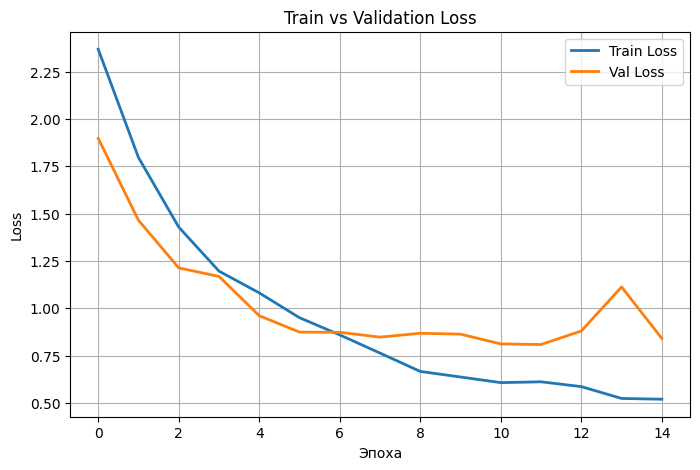

In [98]:
model = train_model_with_val(
    model, loss_fn, optimizer, 
    train_loader_nv, val_loader_nv, 
    epochs=20, patience=3
)

Accuracy: 0.7685009487666035
              precision    recall  f1-score   support

           0       0.75      0.51      0.61        80
           1       0.54      0.62      0.58        48
           2       0.82      0.66      0.73        80
           3       0.76      0.82      0.79        80
           4       0.82      0.77      0.80        48
           5       0.81      0.90      0.85        80
           6       0.88      0.88      0.88        80
           7       0.98      0.92      0.95        50
           8       0.89      0.90      0.89        80
           9       0.74      0.82      0.78        51
          10       0.81      0.76      0.79        80
          11       0.66      0.59      0.62        80
          12       0.85      0.78      0.81        80
          13       0.65      0.79      0.71        80
          14       0.63      0.84      0.72        57

    accuracy                           0.77      1054
   macro avg       0.77      0.77      0.77      10

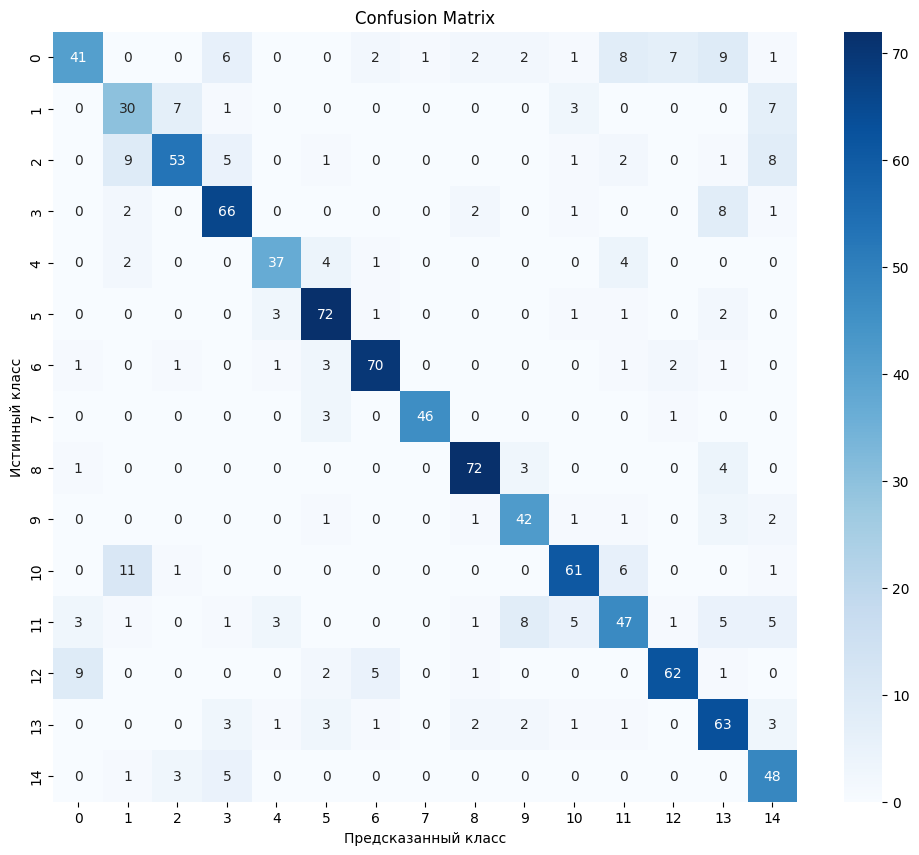

In [99]:
predict_and_print_metrics(model, test_loader_nv, y_test_tensor)

#### 4.1.2.3. <a id='toc4_1_2_3_'></a>[Реализация нейронной сети (FastText)](#toc0_)


In [100]:
model = BiRNNWithPretrainedEmbedding(
    embedding_layer=embedding_layer_ft,
    hidden_size=512,
    num_classes=15,
    bidirectional=True,
    dropout_1=0.3,
    dropout_2=0.15
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

Эпоха  2 | Train Loss: 2.6960 | Val Loss: 2.6911
Эпоха  4 | Train Loss: 2.6888 | Val Loss: 2.6876
Эпоха  6 | Train Loss: 2.6888 | Val Loss: 2.6874
Эпоха  8 | Train Loss: 2.6886 | Val Loss: 2.6873
Эпоха 10 | Train Loss: 2.6883 | Val Loss: 2.6873
Эпоха 12 | Train Loss: 2.6884 | Val Loss: 2.6873
Эпоха 14 | Train Loss: 2.6886 | Val Loss: 2.6873

Ранняя остановка на эпохе 14! Val loss не улучшался 3 эпох.


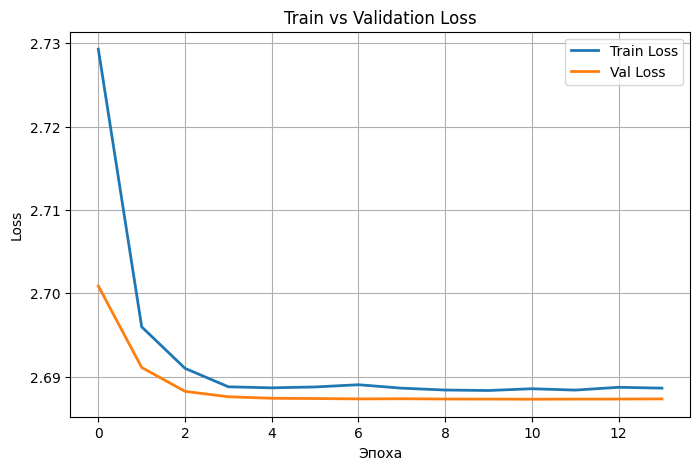

In [101]:
model = train_model_with_val(
    model, loss_fn, optimizer, 
    train_loader_ft, val_loader_ft, 
    epochs=20, patience=3
)

Accuracy: 0.07590132827324478
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        80
           1       0.00      0.00      0.00        48
           2       0.00      0.00      0.00        80
           3       0.00      0.00      0.00        80
           4       0.00      0.00      0.00        48
           5       0.00      0.00      0.00        80
           6       0.00      0.00      0.00        80
           7       0.00      0.00      0.00        50
           8       0.00      0.00      0.00        80
           9       0.00      0.00      0.00        51
          10       0.00      0.00      0.00        80
          11       0.08      1.00      0.14        80
          12       0.00      0.00      0.00        80
          13       0.00      0.00      0.00        80
          14       0.00      0.00      0.00        57

    accuracy                           0.08      1054
   macro avg       0.01      0.07      0.01      1

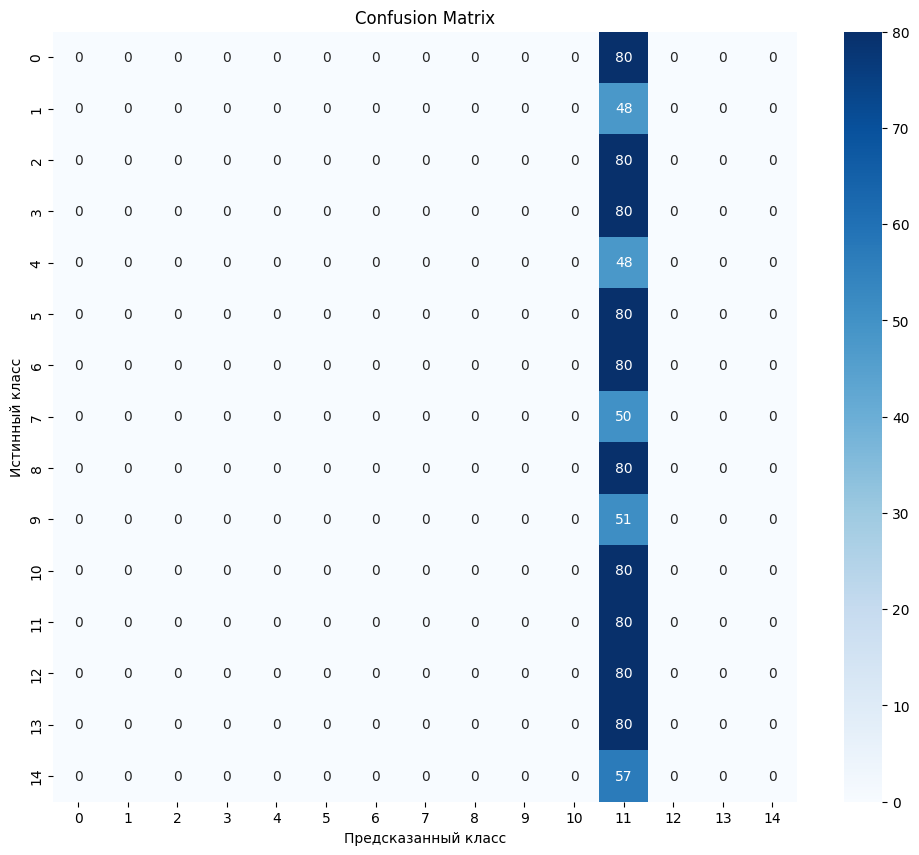

In [102]:
predict_and_print_metrics(model, test_loader_ft, y_test_tensor)

#### 4.1.2.4. <a id='toc4_1_2_4_'></a>[Реализация нейронной сети (NN-эмбеддинги)](#toc0_)


In [103]:
model = BiRNNWithPretrainedEmbedding(
    embedding_layer=embedding_layer_nnemb,
    hidden_size=512,
    num_classes=15,
    bidirectional=True,
    dropout_1=0.2,
    dropout_2=0.1
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Эпоха  2 | Train Loss: 1.9623 | Val Loss: 1.6299
Эпоха  4 | Train Loss: 1.0547 | Val Loss: 1.4993
Эпоха  6 | Train Loss: 0.9583 | Val Loss: 1.1706
Эпоха  8 | Train Loss: 0.5925 | Val Loss: 1.1183
Эпоха 10 | Train Loss: 0.4106 | Val Loss: 1.2235

Ранняя остановка на эпохе 10! Val loss не улучшался 3 эпох.


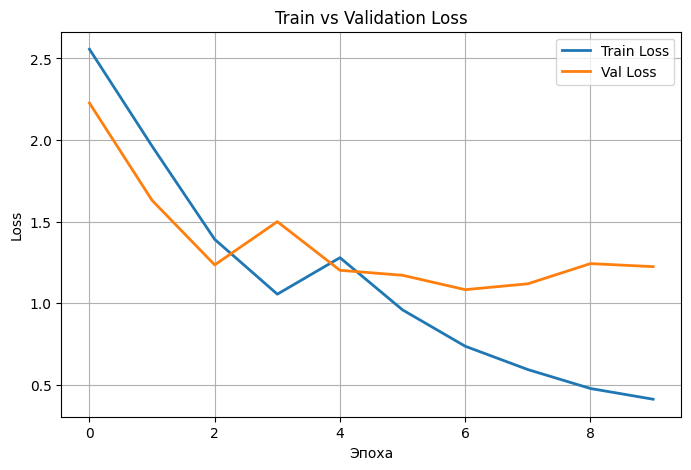

In [104]:
model = train_model_with_val(
    model, loss_fn, optimizer, 
    train_loader_nnemb, val_loader_nnemb, 
    epochs=20, patience=3
)

Accuracy: 0.681214421252372
              precision    recall  f1-score   support

           0       0.55      0.40      0.46        80
           1       0.46      0.52      0.49        48
           2       0.70      0.61      0.65        80
           3       0.56      0.62      0.59        80
           4       0.94      0.62      0.75        48
           5       0.71      0.84      0.77        80
           6       0.85      0.84      0.84        80
           7       1.00      0.86      0.92        50
           8       0.79      0.88      0.83        80
           9       0.50      0.76      0.60        51
          10       0.77      0.86      0.81        80
          11       0.43      0.26      0.33        80
          12       0.81      0.91      0.86        80
          13       0.65      0.66      0.65        80
          14       0.55      0.53      0.54        57

    accuracy                           0.68      1054
   macro avg       0.68      0.68      0.67      105

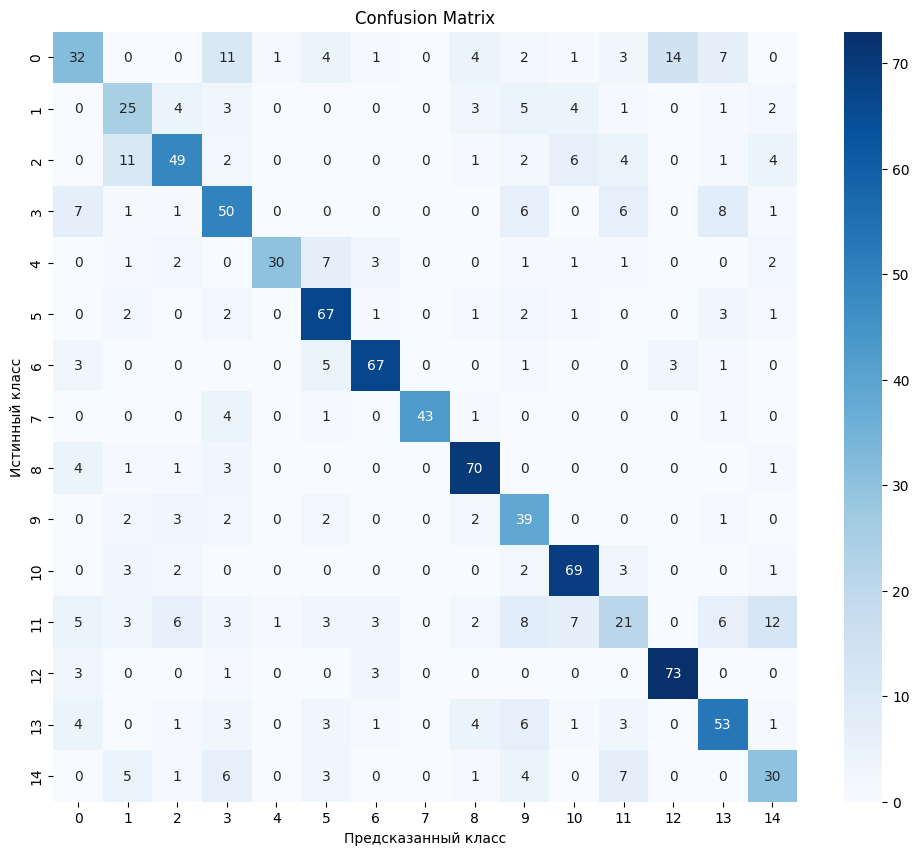

In [105]:
predict_and_print_metrics(model, test_loader_nnemb, y_test_tensor)

### 4.1.3. <a id='toc4_1_3_'></a>[Сеть на базе блока LSTM (biLSTM)](#toc0_)


#### 4.1.3.1. <a id='toc4_1_3_1_'></a>[Реализация нейронной сети](#toc0_)


In [106]:
class BiLSTMWithPretrainedEmbedding(nn.Module):
    def __init__(self, embedding_layer, hidden_size=256, num_classes=15, bidirectional=True,
                 dropout_1=0.3, dropout_2=0.2):
        super().__init__()

        self.embedding = embedding_layer

        self.lstm = nn.LSTM(
            input_size=self.embedding.embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.2
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 60),
            nn.ReLU(),
            nn.Dropout(dropout_1),

            nn.Linear(60, 20),
            nn.ReLU(),
            nn.Dropout(dropout_2),

            nn.Linear(20, num_classes)
        )

    def forward(self, x):
        emb = self.embedding(x)

        lstm_out, (h_n, c_n) = self.lstm(emb) # h_n shape: [num_layers * num_directions, batch, hidden_size]
        # Для BiLSTM берём:
        #  - предпоследний слой → forward направление
        #  - последний слой → backward направление
        h_forward = h_n[-2]     # [batch, hidden_size]
        h_backward = h_n[-1]    # [batch, hidden_size]

        h_last = torch.cat((h_forward, h_backward), dim=1)

        logits = self.classifier(h_last)
        return logits


#### 4.1.3.2. <a id='toc4_1_3_2_'></a>[Реализация нейронной сети (Navec)](#toc0_)


In [107]:
model = BiLSTMWithPretrainedEmbedding(
    embedding_layer=embedding_layer_nv,
    hidden_size=256,
    num_classes=15,
    bidirectional=True,
    dropout_1=0.2,
    dropout_2=0.1
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0025)

Эпоха  2 | Train Loss: 1.5650 | Val Loss: 1.2675
Эпоха  4 | Train Loss: 0.7270 | Val Loss: 0.7148
Эпоха  6 | Train Loss: 0.3872 | Val Loss: 0.7137
Эпоха  8 | Train Loss: 0.2439 | Val Loss: 0.6789

Ранняя остановка на эпохе 8! Val loss не улучшался 3 эпох.


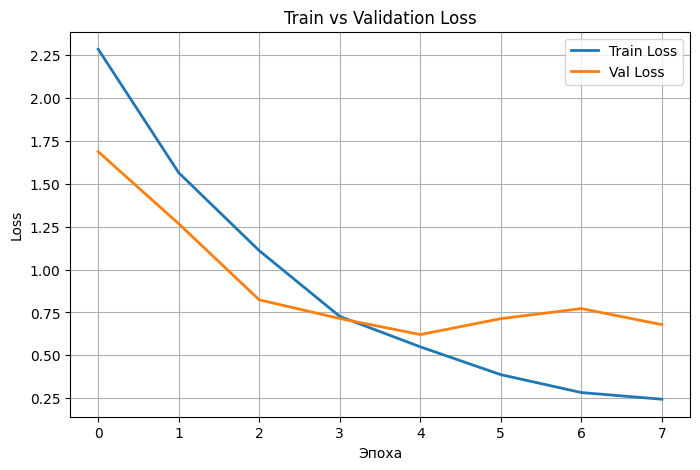

BiLSTMWithPretrainedEmbedding(
  (embedding): Embedding(5644, 300)
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=60, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=60, out_features=20, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=20, out_features=15, bias=True)
  )
)

In [108]:
train_model_with_val(model, loss_fn, optimizer, train_loader_nv, val_loader_nv, epochs=20, patience=3)

Accuracy: 0.8178368121442126
              precision    recall  f1-score   support

           0       0.66      0.64      0.65        80
           1       0.94      0.65      0.77        48
           2       0.91      0.76      0.83        80
           3       0.86      0.82      0.84        80
           4       0.83      0.73      0.78        48
           5       0.88      0.88      0.88        80
           6       0.85      0.80      0.83        80
           7       0.98      0.96      0.97        50
           8       0.94      0.90      0.92        80
           9       0.93      0.84      0.89        51
          10       0.86      0.93      0.89        80
          11       0.59      0.81      0.68        80
          12       0.76      0.89      0.82        80
          13       0.90      0.70      0.79        80
          14       0.69      0.96      0.80        57

    accuracy                           0.82      1054
   macro avg       0.84      0.82      0.82      10

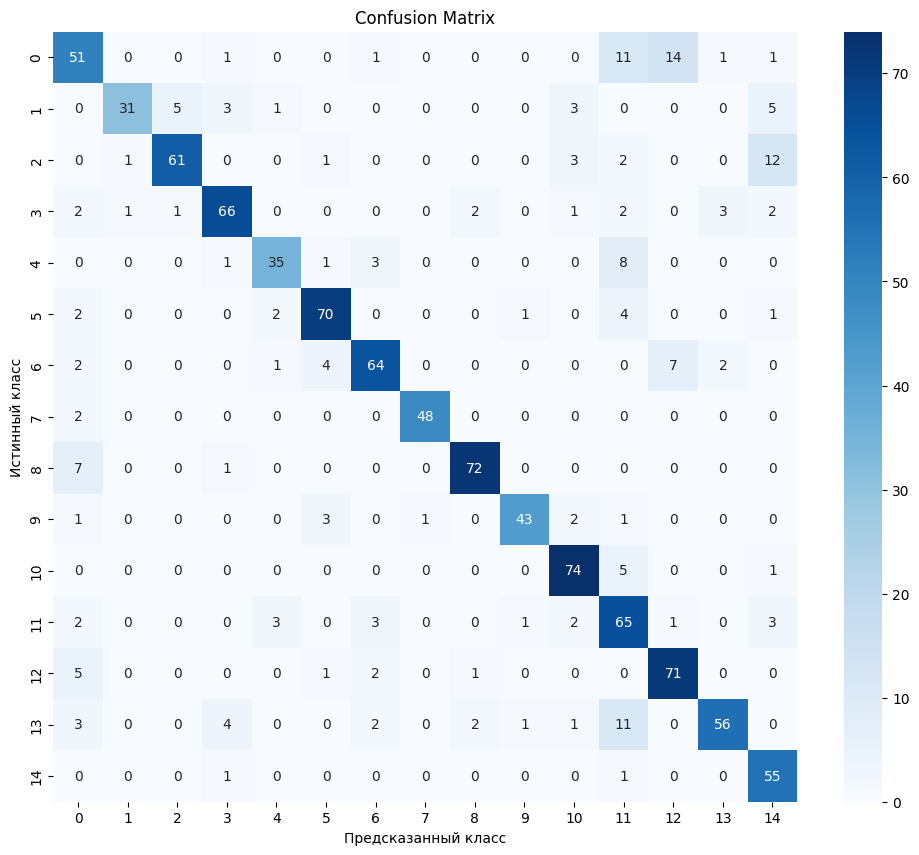

In [109]:
predict_and_print_metrics(model, test_loader_nv, y_test_tensor)

#### 4.1.3.3. <a id='toc4_1_3_3_'></a>[Реализация нейронной сети (FastText)](#toc0_)


In [110]:
model = BiLSTMWithPretrainedEmbedding(
    embedding_layer=embedding_layer_ft,
    hidden_size=512,
    num_classes=15,
    bidirectional=True,
    dropout_1=0.3,
    dropout_2=0.15
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

Эпоха  2 | Train Loss: 2.2478 | Val Loss: 2.2794
Эпоха  4 | Train Loss: 1.9960 | Val Loss: 1.9947
Эпоха  6 | Train Loss: 1.7970 | Val Loss: 1.7452
Эпоха  8 | Train Loss: 1.6092 | Val Loss: 1.5842
Эпоха 10 | Train Loss: 1.5105 | Val Loss: 1.5445
Эпоха 12 | Train Loss: 1.3468 | Val Loss: 1.4982
Эпоха 14 | Train Loss: 1.2391 | Val Loss: 1.4225
Эпоха 16 | Train Loss: 1.1837 | Val Loss: 1.3472
Эпоха 18 | Train Loss: 1.0361 | Val Loss: 1.1617
Эпоха 20 | Train Loss: 0.9713 | Val Loss: 1.1713


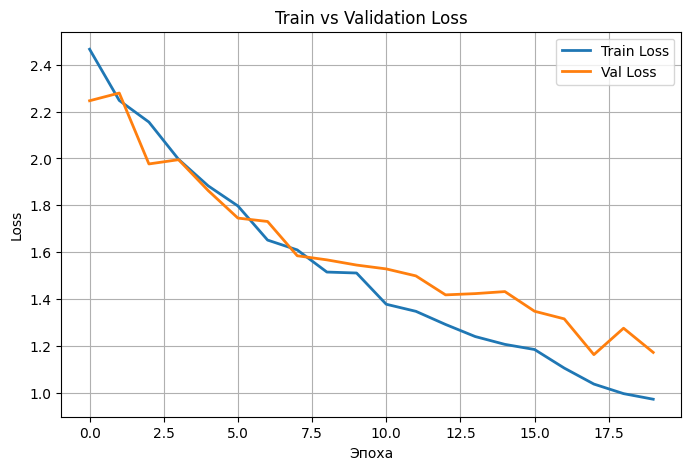

In [111]:
model = train_model_with_val(
    model, loss_fn, optimizer, 
    train_loader_ft, val_loader_ft, 
    epochs=20, patience=3
)

Accuracy: 0.6166982922201139
              precision    recall  f1-score   support

           0       0.55      0.56      0.56        80
           1       0.00      0.00      0.00        48
           2       0.76      0.74      0.75        80
           3       0.57      0.47      0.52        80
           4       0.48      0.62      0.54        48
           5       0.89      0.72      0.80        80
           6       0.82      0.76      0.79        80
           7       1.00      0.78      0.88        50
           8       0.96      0.85      0.90        80
           9       0.00      0.00      0.00        51
          10       0.49      0.66      0.56        80
          11       0.37      0.51      0.43        80
          12       0.59      0.88      0.71        80
          13       0.66      0.46      0.54        80
          14       0.42      0.89      0.57        57

    accuracy                           0.62      1054
   macro avg       0.57      0.59      0.57      10

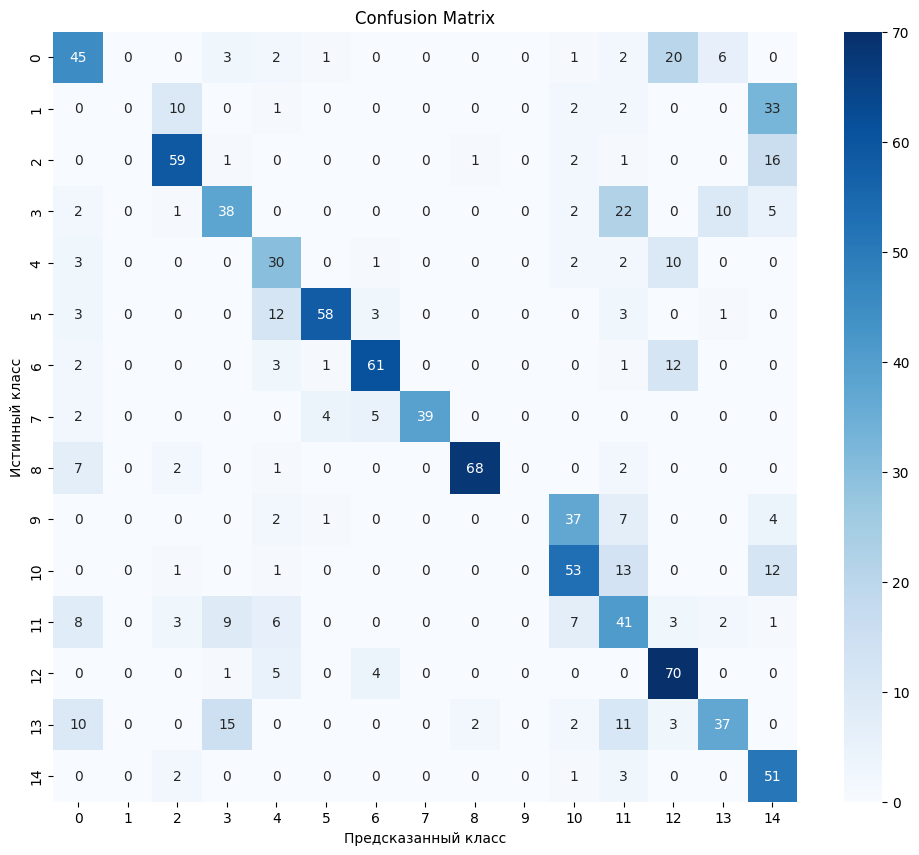

In [112]:
predict_and_print_metrics(model, test_loader_ft, y_test_tensor)

#### 4.1.3.4. <a id='toc4_1_3_4_'></a>[Реализация нейронной сети (NN-эмбеддинги)](#toc0_)


In [113]:
model = BiLSTMWithPretrainedEmbedding(
    embedding_layer=embedding_layer_nnemb,
    hidden_size=512,
    num_classes=15,
    bidirectional=True,
    dropout_1=0.2,
    dropout_2=0.1
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Эпоха  2 | Train Loss: 1.7348 | Val Loss: 1.5985
Эпоха  4 | Train Loss: 0.8180 | Val Loss: 1.3351
Эпоха  6 | Train Loss: 0.4203 | Val Loss: 1.3962

Ранняя остановка на эпохе 7! Val loss не улучшался 3 эпох.


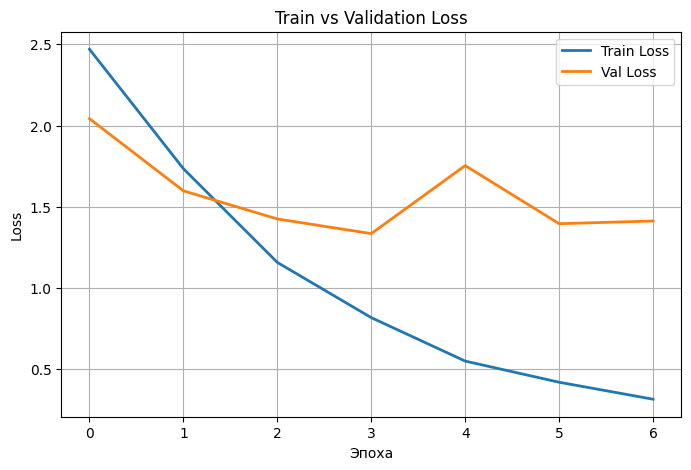

In [114]:
model = train_model_with_val(
    model, loss_fn, optimizer, 
    train_loader_nnemb, val_loader_nnemb, 
    epochs=20, patience=3
)

Accuracy: 0.7191650853889943
              precision    recall  f1-score   support

           0       0.54      0.54      0.54        80
           1       0.64      0.60      0.62        48
           2       0.82      0.61      0.70        80
           3       0.84      0.64      0.72        80
           4       0.73      0.73      0.73        48
           5       0.69      0.82      0.75        80
           6       0.83      0.80      0.82        80
           7       0.96      0.92      0.94        50
           8       0.87      0.91      0.89        80
           9       0.72      0.71      0.71        51
          10       0.54      0.90      0.67        80
          11       0.55      0.39      0.46        80
          12       0.80      0.88      0.83        80
          13       0.80      0.61      0.70        80
          14       0.66      0.77      0.71        57

    accuracy                           0.72      1054
   macro avg       0.73      0.72      0.72      10

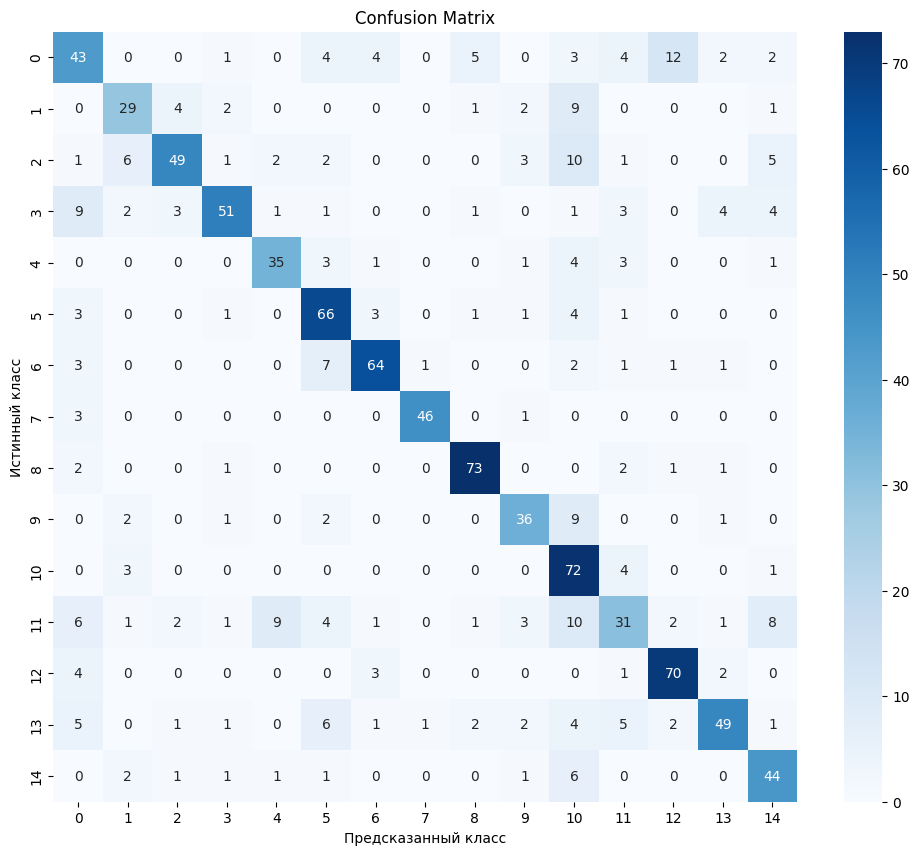

In [115]:
predict_and_print_metrics(model, test_loader_nnemb, y_test_tensor)

### 4.1.4. <a id='toc4_1_4_'></a>[Сеть на базе блока GRU (biGRU)](#toc0_)


#### 4.1.4.1. <a id='toc4_1_4_1_'></a>[Реализация нейронной сети](#toc0_)


In [116]:
class BiGRUWithPretrainedEmbedding(nn.Module):
    def __init__(self, embedding_layer, hidden_size=256, num_classes=15, bidirectional=True,
                 dropout_1=0.3, dropout_2=0.2):
        super().__init__()

        self.embedding = embedding_layer

        self.gru = nn.GRU(
            input_size=self.embedding.embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.2
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 60),
            nn.ReLU(),
            nn.Dropout(dropout_1),

            nn.Linear(60, 20),
            nn.ReLU(),
            nn.Dropout(dropout_2),

            nn.Linear(20, num_classes)
        )

    def forward(self, x):
        emb = self.embedding(x)   # [batch, seq_len, embedding_dim]

        # GRU не возвращает c_n — только h_n
        gru_out, h_n = self.gru(emb) # h_n shape: [num_layers * num_directions, batch, hidden_size]
        # Для BiGRU берём:
        #  - h_n[-2] → forward направления последнего слоя
        #  - h_n[-1] → backward направления последнего слоя
        h_forward = h_n[-2]     # [batch, hidden_size]
        h_backward = h_n[-1]    # [batch, hidden_size]

        # Соединяем два направления
        h_last = torch.cat((h_forward, h_backward), dim=1)

        logits = self.classifier(h_last)
        return logits


#### 4.1.4.2. <a id='toc4_1_4_2_'></a>[Реализация нейронной сети (Navec)](#toc0_)


In [117]:
model = BiGRUWithPretrainedEmbedding(
    embedding_layer=embedding_layer_nv,
    hidden_size=256,
    num_classes=15,
    bidirectional=True,
    dropout_1=0.2,
    dropout_2=0.1
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0025)

Эпоха  2 | Train Loss: 1.2957 | Val Loss: 0.9337
Эпоха  4 | Train Loss: 0.6209 | Val Loss: 0.7219
Эпоха  6 | Train Loss: 0.3833 | Val Loss: 0.8823
Эпоха  8 | Train Loss: 0.2471 | Val Loss: 0.7487

Ранняя остановка на эпохе 8! Val loss не улучшался 3 эпох.


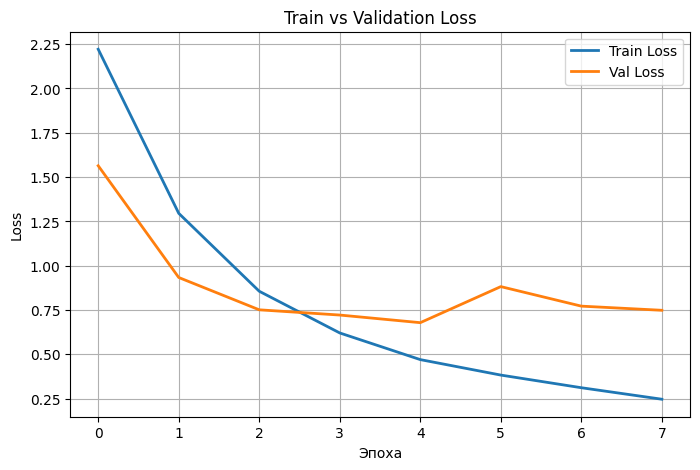

BiGRUWithPretrainedEmbedding(
  (embedding): Embedding(5644, 300)
  (gru): GRU(300, 256, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=60, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=60, out_features=20, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=20, out_features=15, bias=True)
  )
)

In [118]:
train_model_with_val(model, loss_fn, optimizer, train_loader_nv, val_loader_nv, epochs=20, patience=3)

Accuracy: 0.8206831119544592
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        80
           1       0.65      0.88      0.74        48
           2       0.95      0.68      0.79        80
           3       0.84      0.86      0.85        80
           4       0.90      0.73      0.80        48
           5       0.83      0.93      0.88        80
           6       0.86      0.90      0.88        80
           7       0.98      0.96      0.97        50
           8       0.94      0.90      0.92        80
           9       0.87      0.80      0.84        51
          10       0.87      0.85      0.86        80
          11       0.75      0.68      0.71        80
          12       0.80      0.90      0.85        80
          13       0.70      0.80      0.74        80
          14       0.80      0.91      0.85        57

    accuracy                           0.82      1054
   macro avg       0.83      0.82      0.82      10

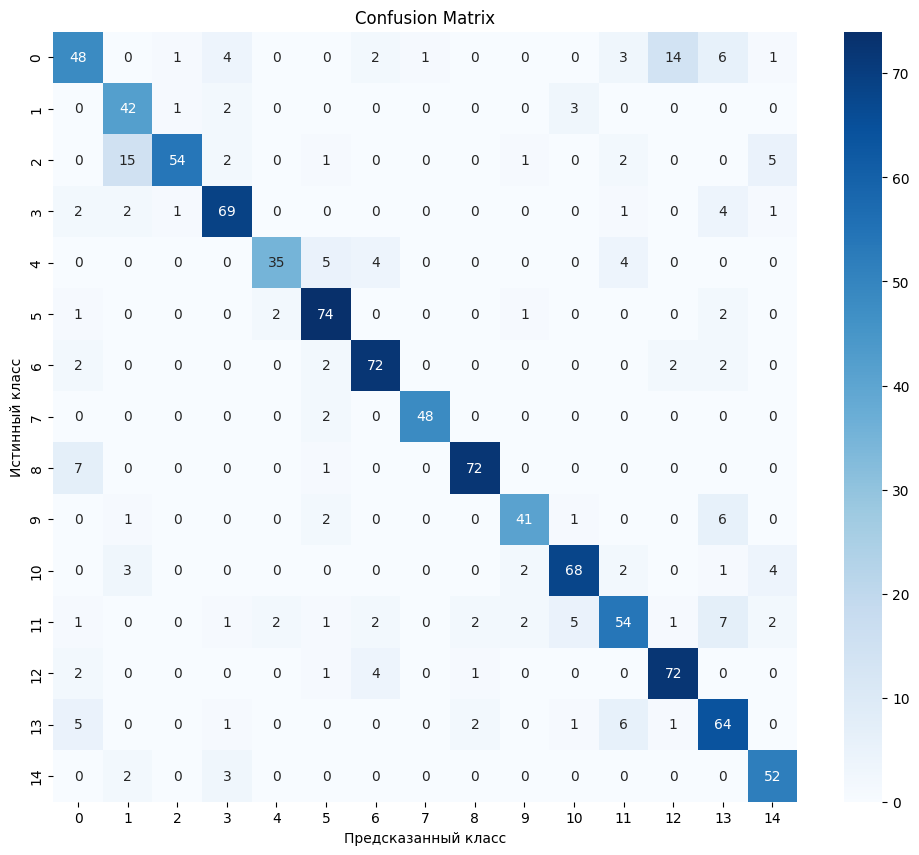

In [119]:
predict_and_print_metrics(model, test_loader_nv, y_test_tensor)

#### 4.1.4.3. <a id='toc4_1_4_3_'></a>[Реализация нейронной сети (FastText)](#toc0_)


In [120]:
model = BiGRUWithPretrainedEmbedding(
    embedding_layer=embedding_layer_ft,
    hidden_size=512,
    num_classes=15,
    bidirectional=True,
    dropout_1=0.3,
    dropout_2=0.15
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

Эпоха  2 | Train Loss: 1.1803 | Val Loss: 1.0764
Эпоха  4 | Train Loss: 0.8381 | Val Loss: 0.9225
Эпоха  6 | Train Loss: 0.6848 | Val Loss: 0.9217
Эпоха  8 | Train Loss: 0.6454 | Val Loss: 1.0276
Эпоха 10 | Train Loss: 0.5956 | Val Loss: 1.0125
Эпоха 12 | Train Loss: 0.6035 | Val Loss: 1.0383

Ранняя остановка на эпохе 12! Val loss не улучшался 3 эпох.


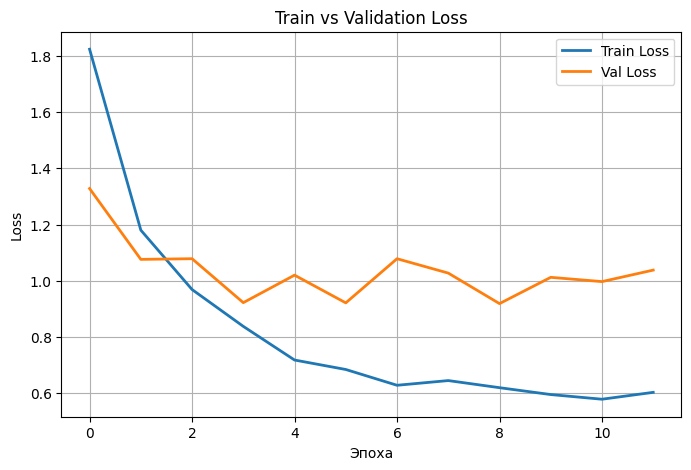

In [121]:
model = train_model_with_val(
    model, loss_fn, optimizer, 
    train_loader_ft, val_loader_ft, 
    epochs=20, patience=3
)

Accuracy: 0.6963946869070209
              precision    recall  f1-score   support

           0       0.62      0.49      0.55        80
           1       0.43      0.73      0.54        48
           2       0.81      0.65      0.72        80
           3       0.78      0.88      0.82        80
           4       0.91      0.44      0.59        48
           5       0.68      0.90      0.77        80
           6       0.74      0.85      0.79        80
           7       0.96      0.92      0.94        50
           8       0.87      0.90      0.88        80
           9       0.75      0.24      0.36        51
          10       0.52      0.80      0.63        80
          11       0.62      0.49      0.55        80
          12       0.73      0.76      0.74        80
          13       0.79      0.68      0.73        80
          14       0.57      0.51      0.54        57

    accuracy                           0.70      1054
   macro avg       0.72      0.68      0.68      10

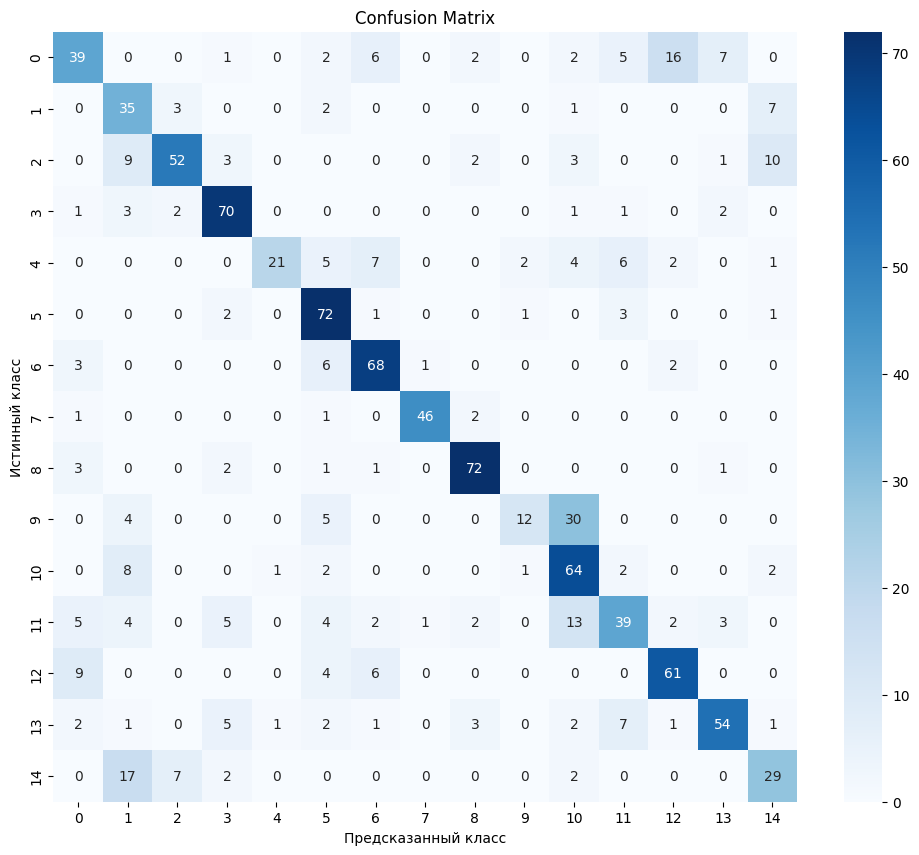

In [122]:
predict_and_print_metrics(model, test_loader_ft, y_test_tensor)

#### 4.1.4.4. <a id='toc4_1_4_4_'></a>[Реализация нейронной сети (NN-эмбеддинги)](#toc0_)


In [123]:
model = BiGRUWithPretrainedEmbedding(
    embedding_layer=embedding_layer_nnemb,
    hidden_size=512,
    num_classes=15,
    bidirectional=True,
    dropout_1=0.2,
    dropout_2=0.1
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Эпоха  2 | Train Loss: 1.4593 | Val Loss: 1.2278
Эпоха  4 | Train Loss: 0.5865 | Val Loss: 1.1804
Эпоха  6 | Train Loss: 0.3238 | Val Loss: 1.3554

Ранняя остановка на эпохе 7! Val loss не улучшался 3 эпох.


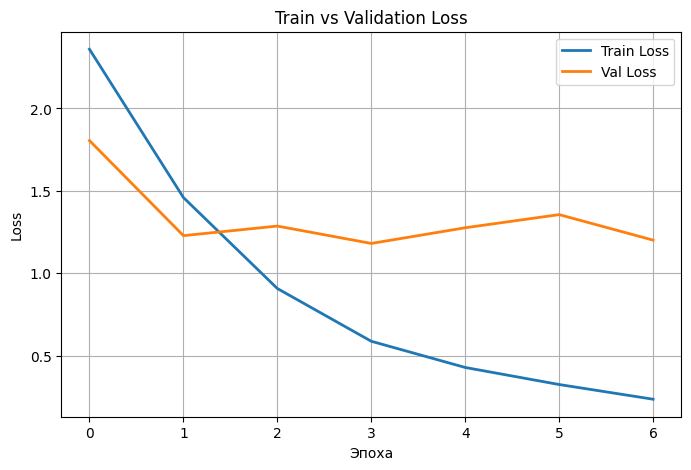

In [124]:
model = train_model_with_val(
    model, loss_fn, optimizer, 
    train_loader_nnemb, val_loader_nnemb, 
    epochs=20, patience=3
)

Accuracy: 0.7106261859582542
              precision    recall  f1-score   support

           0       0.50      0.56      0.53        80
           1       0.43      0.65      0.52        48
           2       0.88      0.62      0.73        80
           3       0.67      0.57      0.62        80
           4       0.74      0.71      0.72        48
           5       0.75      0.79      0.77        80
           6       0.87      0.85      0.86        80
           7       0.83      0.90      0.87        50
           8       0.95      0.86      0.90        80
           9       0.73      0.80      0.77        51
          10       0.73      0.75      0.74        80
          11       0.54      0.47      0.51        80
          12       0.82      0.89      0.85        80
          13       0.73      0.66      0.69        80
          14       0.56      0.61      0.58        57

    accuracy                           0.71      1054
   macro avg       0.71      0.71      0.71      10

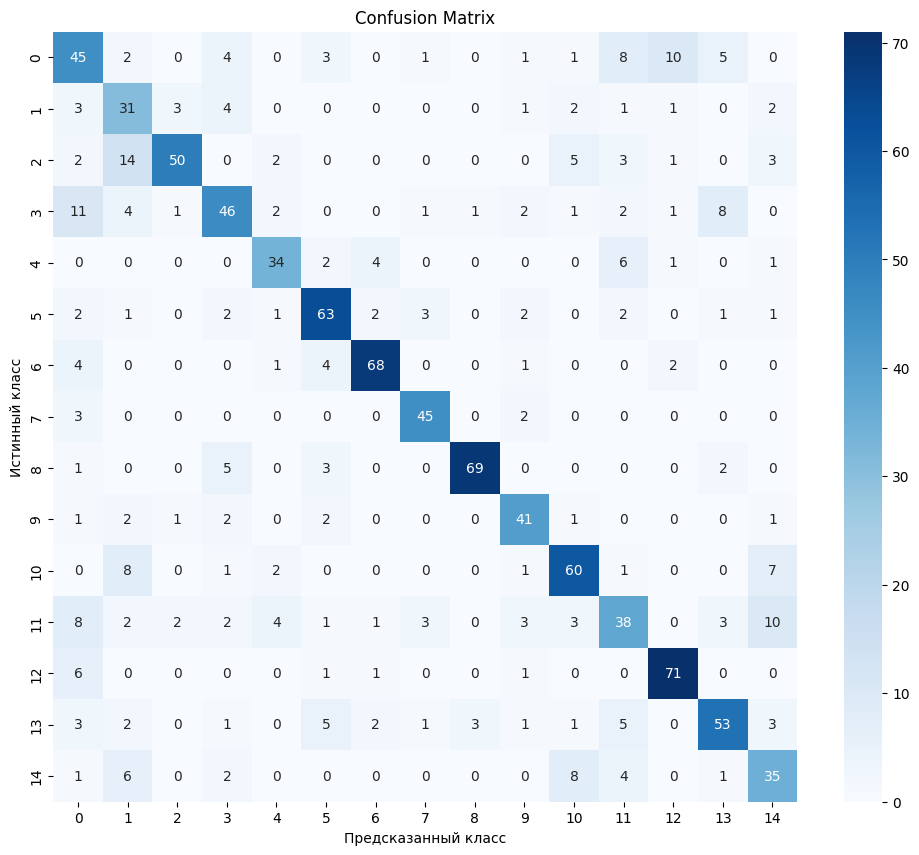

In [125]:
predict_and_print_metrics(model, test_loader_nnemb, y_test_tensor)

### 4.1.5. <a id='toc4_1_5_'></a>[Сеть на базе блока GRU (ручная реализация)](#toc0_)


#### 4.1.5.1. <a id='toc4_1_5_1_'></a>[Формулы GRU](#toc0_)

**Формулы:**

**Вентиль сброса (Reset Gate, $r_t$)**: определяет, какую часть информации из прошлого ($H_{t-1}$) следует игнорировать при вычислении нового состояния

$$r_t = \sigma(W_r \cdot [H_{t-1}, x_t] + b_r)$$

**Вентиль обновления (Update Gate, $z_t$)**: определяет, какую долю информации из прошлого состояния $H_{t-1}$ следует сохранить, а какую — заменить новым состоянием

$$z_t = \sigma(W_z \cdot [H_{t-1}, x_t] + b_z)$$

**Кандидатное скрытое состояние ($\tilde{H}_t$)**: содержит информацию из текущего входа и отфильтрованную информацию из прошлого

$$\tilde{H}_t = \tanh(W_h \cdot [r_t \odot H_{t-1}, x_t] + b_H)$$

**Итоговое скрытое состояние ($H_t$)**:

$$H_t = (1 - z_t) \odot H_{t-1} + z_t \odot \tilde{H}_t$$


In [126]:
class MyGRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # Update Gate, z
        self.W_z = nn.Linear(input_size, hidden_size, bias=True)
        self.U_z = nn.Linear(hidden_size, hidden_size, bias=False)

        # Reset Gate, r
        self.W_r = nn.Linear(input_size, hidden_size, bias=True)
        self.U_r = nn.Linear(hidden_size, hidden_size, bias=False)

        # Candidate h̃
        self.W_h = nn.Linear(input_size, hidden_size, bias=True)
        self.U_h = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev):
        z_t = torch.sigmoid(self.W_z(x_t) + self.U_z(h_prev))
        r_t = torch.sigmoid(self.W_r(x_t) + self.U_r(h_prev))
        h_tilde = torch.tanh(self.W_h(x_t) + self.U_h(r_t * h_prev))
        h_t = (1 - z_t) * h_prev + z_t * h_tilde
        return h_t

In [127]:
class MyGRULayer(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = MyGRUCell(input_size, hidden_size)

    def forward(self, x):
        # x: [batch, seq_len, input_size]
        batch_size, seq_len, _ = x.size()

        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []

        for t in range(seq_len):
            h = self.cell(x[:, t, :], h)
            outputs.append(h.unsqueeze(1))

        return torch.cat(outputs, dim=1), h

#### 4.1.5.2. <a id='toc4_1_5_2_'></a>[Реализация нейронной сети](#toc0_)


In [128]:
class MyGRUClassifier(nn.Module):
    def __init__(self, embedding_layer, hidden_size=256, num_classes=15):
        super().__init__()

        self.embedding = embedding_layer

        self.gru = MyGRULayer(
            input_size=self.embedding.embedding_dim,
            hidden_size=hidden_size
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 80),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(80, 30),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(30, num_classes)
        )

    def forward(self, x):
        emb = self.embedding(x)
        out, h_last = self.gru(emb)
        # h_last — состояние последнего шага
        logits = self.fc(h_last)
        return logits

#### 4.1.5.3. <a id='toc4_1_5_3_'></a>[Реализация нейронной сети (Navec)](#toc0_)


In [129]:
model = MyGRUClassifier(
    embedding_layer=embedding_layer_nv,
    hidden_size=256,
    num_classes=15
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

Эпоха  2 | Train Loss: 2.6577 | Val Loss: 2.4748
Эпоха  4 | Train Loss: 2.0312 | Val Loss: 1.7033
Эпоха  6 | Train Loss: 1.2782 | Val Loss: 1.2811
Эпоха  8 | Train Loss: 0.6911 | Val Loss: 0.9504
Эпоха 10 | Train Loss: 0.3834 | Val Loss: 1.0245
Эпоха 12 | Train Loss: 0.2365 | Val Loss: 0.9918

Ранняя остановка на эпохе 12! Val loss не улучшался 3 эпох.


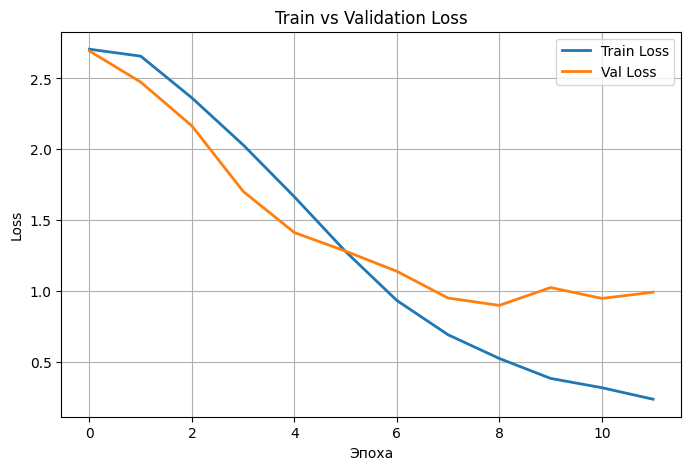

MyGRUClassifier(
  (embedding): Embedding(5644, 300)
  (gru): MyGRULayer(
    (cell): MyGRUCell(
      (W_z): Linear(in_features=300, out_features=256, bias=True)
      (U_z): Linear(in_features=256, out_features=256, bias=False)
      (W_r): Linear(in_features=300, out_features=256, bias=True)
      (U_r): Linear(in_features=256, out_features=256, bias=False)
      (W_h): Linear(in_features=300, out_features=256, bias=True)
      (U_h): Linear(in_features=256, out_features=256, bias=False)
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=80, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=80, out_features=30, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=30, out_features=15, bias=True)
  )
)

In [130]:
train_model_with_val(model, loss_fn, optimizer, train_loader_nv, val_loader_nv, epochs=20, patience=3)

Accuracy: 0.7628083491461101
              precision    recall  f1-score   support

           0       0.54      0.69      0.61        80
           1       0.71      0.62      0.67        48
           2       0.73      0.81      0.77        80
           3       0.70      0.70      0.70        80
           4       0.78      0.81      0.80        48
           5       0.82      0.90      0.86        80
           6       0.92      0.82      0.87        80
           7       0.94      0.94      0.94        50
           8       0.96      0.90      0.93        80
           9       0.71      0.78      0.75        51
          10       0.92      0.74      0.82        80
          11       0.71      0.51      0.59        80
          12       0.81      0.81      0.81        80
          13       0.69      0.62      0.66        80
          14       0.61      0.82      0.70        57

    accuracy                           0.76      1054
   macro avg       0.77      0.77      0.76      10

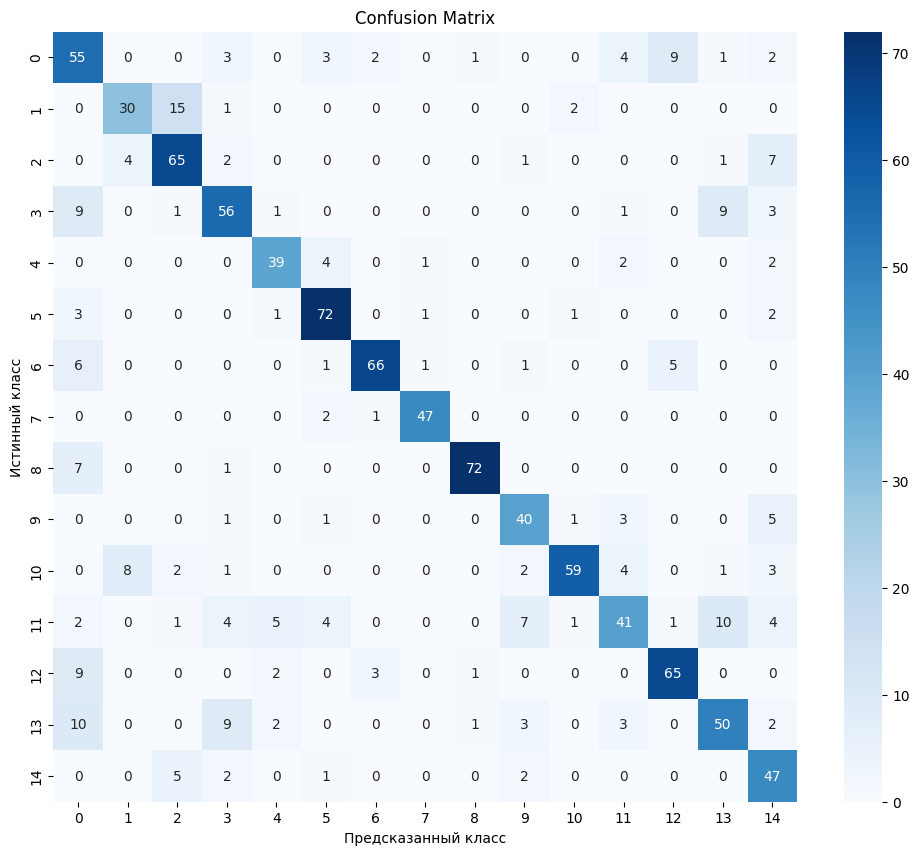

In [131]:
predict_and_print_metrics(model, test_loader_nv, y_test_tensor)

## 5. <a id='toc5_'></a>[Раздел 5. Выводы](#toc0_)


### 5.1. <a id='toc5_1_'></a>[Лучшие модели](#toc0_)

Лучшие модели:
1) сеть на базе блока GRU (biGRU) + Navec embeddings + lemmatization = Accuracy 0.82
2) сеть на базе блока LSTM (biLSTM) + Navec embeddings + lemmatization = Accuracy 0.82
